# Scattering products explorer

This notebook gives a frame-level view of the products discovered below a `giwaxs`, `gisaxs`, or similar reduction folder. It pairs products by their shared reduction-frame name and displays QC, q-image, q–φ, and circular-average data together.

Edit `DATA_ROOT` and `FRAME_INDEX` in the next cell, then run top to bottom.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Make the repository importable when JupyterLab starts in the repo or notebook/ directory.
for candidate in (Path.cwd(), Path.cwd().parent):
    if (candidate / 'NanoOrganizer').is_dir():
        sys.path.insert(0, str(candidate))
        break

from NanoOrganizer.viz.scattering_notebook import (
    load_qimage, load_qphi, plot_qimage, plot_qphi, plot_cir_avg,
    plot_qc_image, qimage_linecuts, product_index,
)

DATA_ROOT = Path('/home/yuzhang/NSLS_II_Link/smi_remote/2026-2/pass-319371/projects/microbeam_Kim/Results/giwaxs')
FRAME_INDEX = 0
MAX_PLOT_PIXELS = 600_000
QX_LIMITS = None       # Example: (-0.5, 3.0)
QZ_LIMITS = None       # Example: (0.0, 3.0)
SAVE_FIGURES = False
OUTPUT_DIR = DATA_ROOT / 'notebook_figures'

## 1. Discover products and choose a frame

The index is based on the common filename stem, so missing products remain visible instead of silently changing the frame pairing.

In [2]:
frame_table = product_index(DATA_ROOT)
if frame_table.empty:
    raise FileNotFoundError(f'No scattering products found below {DATA_ROOT}')

products = ('qc', 'q_image', 'qphi', 'cir_avg')
counts = {product: int(frame_table[f'has_{product}'].sum()) for product in products}
print('Product counts:', counts)
print('Indexed frames:', len(frame_table))
display(frame_table[['stem'] + [f'has_{product}' for product in products]].head(10))

if not 0 <= FRAME_INDEX < len(frame_table):
    raise IndexError(f'FRAME_INDEX={FRAME_INDEX} is outside 0..{len(frame_table) - 1}')
row = frame_table.iloc[FRAME_INDEX]
print('Selected frame:', row['stem'])
display(pd.Series({product: row.get(product) for product in products}, name='path'))

Product counts: {'qc': 994, 'q_image': 994, 'qphi': 994, 'cir_avg': 994}
Indexed frames: 994


,stem,has_qc,has_q_image,has_qphi,has_cir_avg
0,Kim_EUV_10_0.0500deg_x-30160.00_y1770.66_z1600...,True,True,True,True
1,Kim_EUV_10_0.0500deg_x-30160.00_y1770.66_z1600...,True,True,True,True
2,Kim_EUV_10_0.0500deg_x-30660.00_y1770.66_z1600...,True,True,True,True
3,Kim_EUV_10_0.0500deg_x-31160.00_y1770.66_z1600...,True,True,True,True
4,Kim_EUV_10_0.1000deg_x-30160.00_y1770.66_z1600...,True,True,True,True
5,Kim_EUV_10_0.1000deg_x-30660.00_y1770.66_z1600...,True,True,True,True
6,Kim_EUV_10_0.1000deg_x-31160.00_y1770.66_z1600...,True,True,True,True
7,Kim_EUV_10_0.1500deg_x-30160.00_y1770.66_z1600...,True,True,True,True
8,Kim_EUV_10_0.1500deg_x-30660.00_y1770.66_z1600...,True,True,True,True
9,Kim_EUV_10_0.1500deg_x-31160.00_y1770.66_z1600...,True,True,True,True


Selected frame: Kim_EUV_10_0.0500deg_x-30160.00_y1770.66_z1600.00_det5000.00m_waxsSTITCH_expt5s__16.10keV_wa00.0_sdd5.0m_16100.00eV_wa-0.0_sdd5000.0mm_id1149122_000000_WAXS


qc         /mnt/data32/NSLSII_Data/smi_remote/2026-2/pass...
q_image    /mnt/data32/NSLSII_Data/smi_remote/2026-2/pass...
qphi       /mnt/data32/NSLSII_Data/smi_remote/2026-2/pass...
cir_avg    /mnt/data32/NSLSII_Data/smi_remote/2026-2/pass...
Name: path, dtype: object

## 2. Display the selected frame

The q-image panel uses physical qx/qz coordinates, `origin='lower'`, robust logarithmic limits, and the reduction mask. The q–φ panel is only masked when its stored mask has the same shape as the q–φ array.

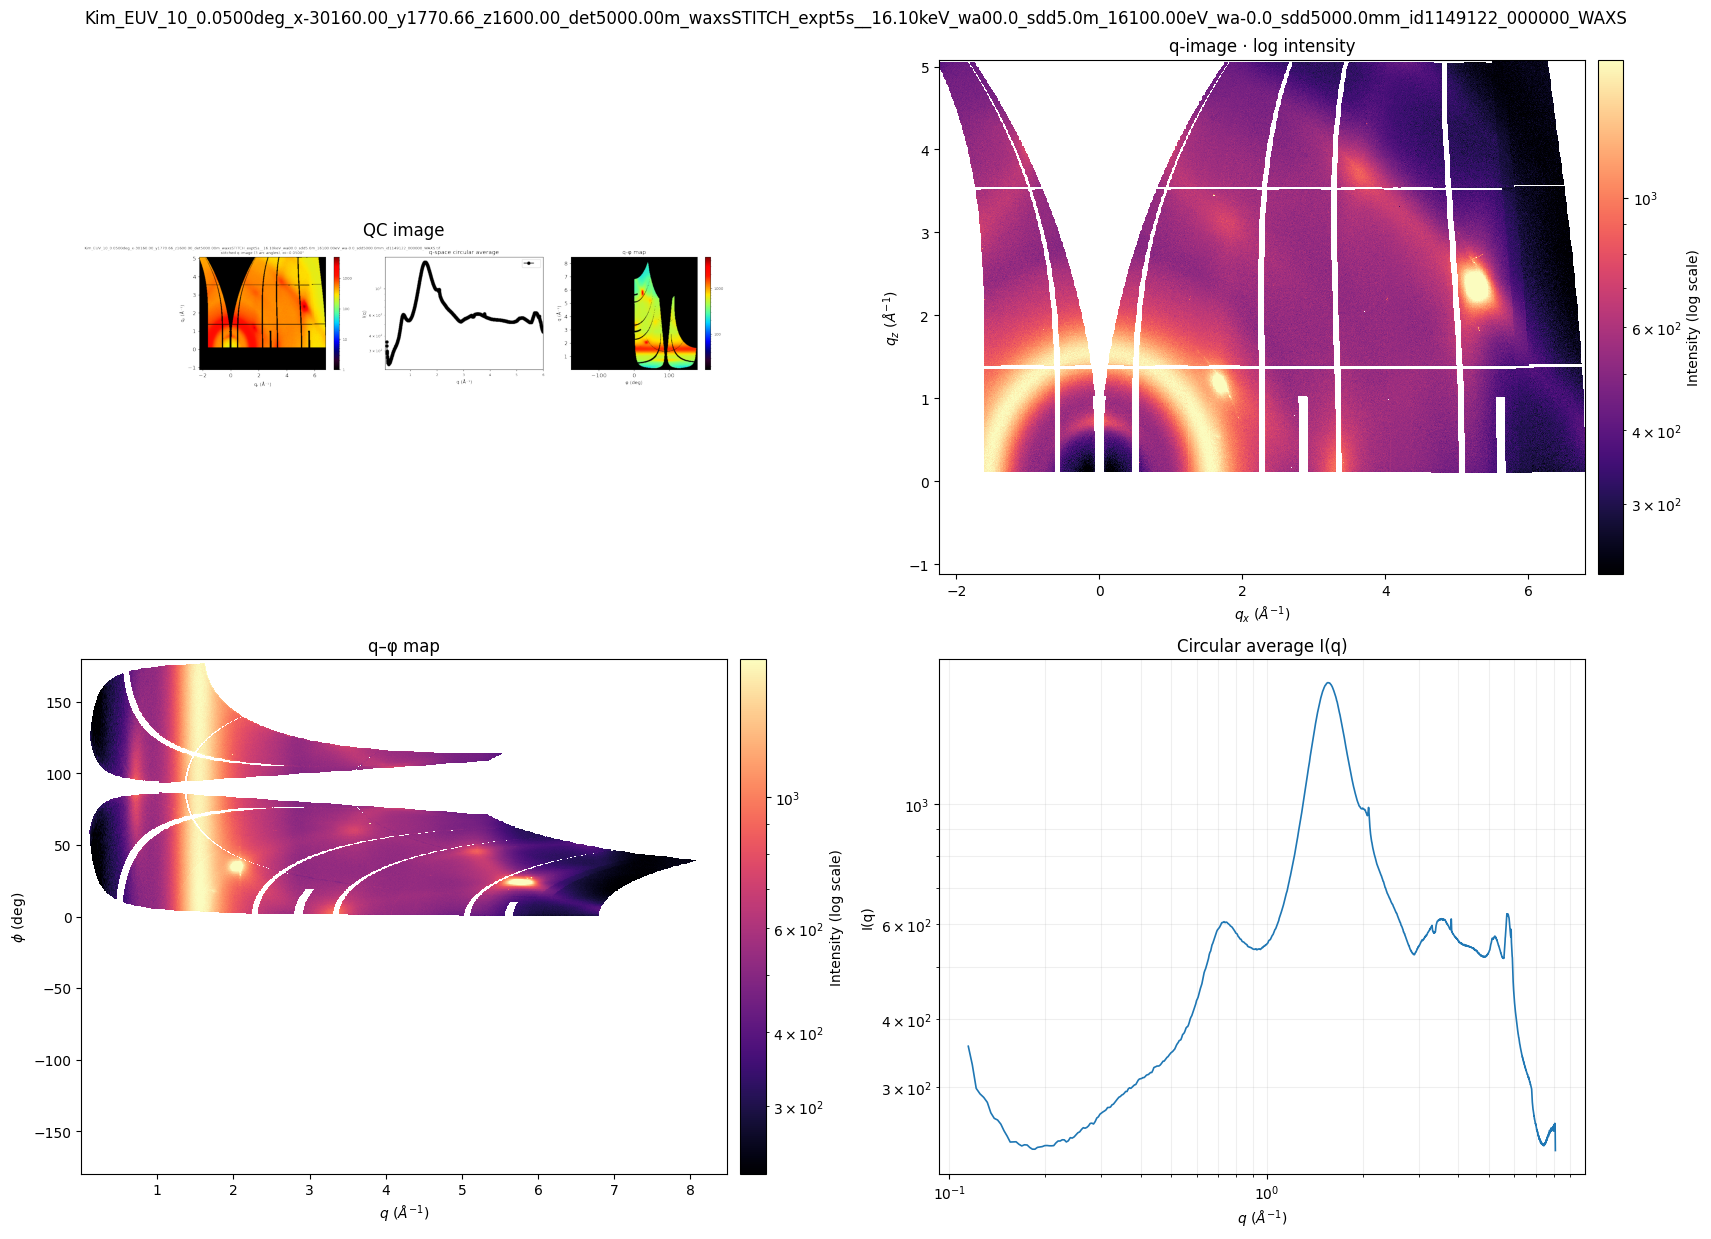

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(17, 12), constrained_layout=True)

if bool(row.get('has_qc', False)):
    plot_qc_image(row['qc'], ax=axes[0, 0], title='QC image')
else:
    axes[0, 0].set_title('QC image unavailable')
    axes[0, 0].set_axis_off()

if bool(row.get('has_q_image', False)):
    qimage = load_qimage(row['q_image'])
    plot_qimage(qimage, ax=axes[0, 1], qxlim=QX_LIMITS, qzlim=QZ_LIMITS,
                log_intensity=True, aspect='auto', max_pixels=MAX_PLOT_PIXELS,
                title='q-image · log intensity')
else:
    axes[0, 1].set_title('q-image unavailable')

if bool(row.get('has_qphi', False)):
    qphi = load_qphi(row['qphi'])
    plot_qphi(qphi, ax=axes[1, 0], log_intensity=True, title='q–φ map')
else:
    axes[1, 0].set_title('q–φ map unavailable')

if bool(row.get('has_cir_avg', False)):
    plot_cir_avg(row['cir_avg'], ax=axes[1, 1], title='Circular average I(q)')
else:
    axes[1, 1].set_title('Circular average unavailable')

fig.suptitle(row['stem'], y=1.02)
selected_fig = fig
plt.show()

## 3. Inspect q-image geometry and line cuts

Use these checks when a GUI panel looks compressed, transposed, or blank. The line cuts use the nearest requested qx/qz coordinate and return masked pixels as NaN.

q-image shape: (3031, 4414)
qx range: (-2.242806285217665, 6.792655809932773)
qz range: (-1.1212310968767392, 5.08258720094919)


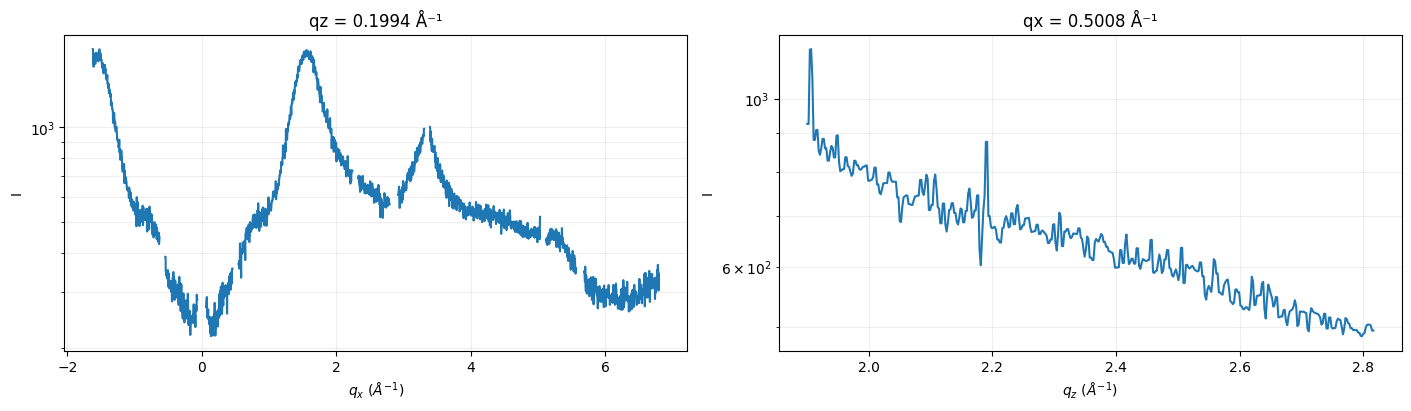

In [4]:
if bool(row.get('has_q_image', False)):
    print('q-image shape:', qimage.intensity.shape)
    print('qx range:', (qimage.qx.min(), qimage.qx.max()))
    print('qz range:', (qimage.qz.min(), qimage.qz.max()))
    CUT_QZ = 0.20
    CUT_QX = 0.50
    cuts = qimage_linecuts(qimage, qx=CUT_QX, qz=CUT_QZ)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
    axes[0].plot(cuts['qx'], cuts['qx_profile'])
    axes[0].set_yscale('log')
    axes[0].set_xlabel(r'$q_x$ ($\AA^{-1}$)')
    axes[0].set_ylabel('I')
    axes[0].set_title(f"qz = {cuts['selected_qz']:.4g} Å⁻¹")
    axes[1].plot(cuts['qz'], cuts['qz_profile'])
    axes[1].set_yscale('log')
    axes[1].set_xlabel(r'$q_z$ ($\AA^{-1}$)')
    axes[1].set_ylabel('I')
    axes[1].set_title(f"qx = {cuts['selected_qx']:.4g} Å⁻¹")
    for ax in axes:
        ax.grid(True, which='both', alpha=0.2)
    linecut_fig = fig
    plt.show()
else:
    print('The selected frame has no q-image product.')

## 4. Compare several frames

Change `COMPARE_INDICES` to inspect a scan or to determine whether a display issue is isolated to one frame.

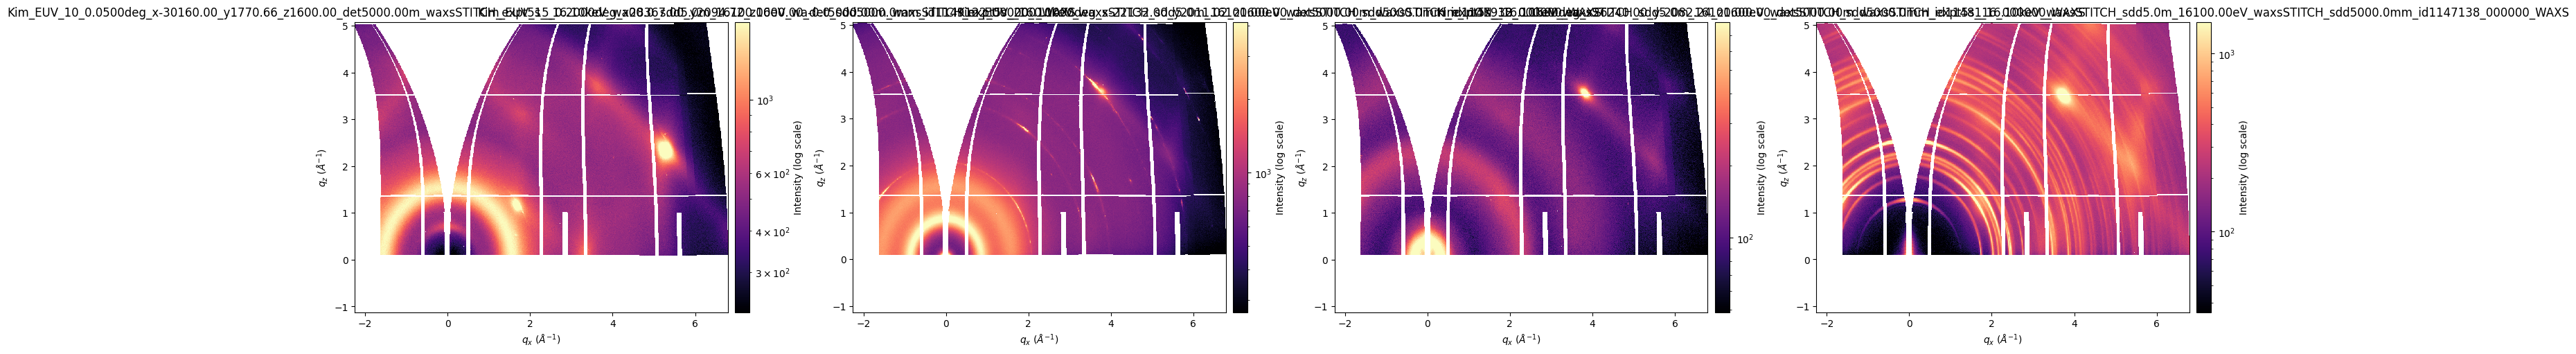

In [5]:
COMPARE_INDICES = [i for i in (0, 100, 200, 500) if i < len(frame_table)]
qimage_rows = [frame_table.iloc[i] for i in COMPARE_INDICES if bool(frame_table.iloc[i].get('has_q_image', False))]

if qimage_rows:
    fig, axes = plt.subplots(1, len(qimage_rows),
                             figsize=(7 * len(qimage_rows), 5),
                             squeeze=False, constrained_layout=True)
    for ax, compare_row in zip(axes[0], qimage_rows):
        compare_data = load_qimage(compare_row['q_image'])
        plot_qimage(compare_data, ax=ax, qxlim=QX_LIMITS, qzlim=QZ_LIMITS,
                    log_intensity=True, aspect='auto', max_pixels=MAX_PLOT_PIXELS,
                    title=compare_row['stem'])
    comparison_fig = fig
    plt.show()
else:
    print('No q-image products were found for COMPARE_INDICES.')

## 5. Optional figure export

Set `SAVE_FIGURES = True` near the top to save the last selected-frame and comparison figures beside the data.

In [6]:
if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    if 'selected_fig' in globals():
        selected_fig.savefig(OUTPUT_DIR / f'frame_{FRAME_INDEX:04d}_overview.png', dpi=150)
    if 'comparison_fig' in globals():
        comparison_fig.savefig(OUTPUT_DIR / 'qimage_comparison.png', dpi=150)
    print(f'Figures saved to {OUTPUT_DIR}')
else:
    print('Figure export is disabled. Set SAVE_FIGURES=True to enable it.')

Figure export is disabled. Set SAVE_FIGURES=True to enable it.
